# Grid Search with Custom Refit Strategy

This notebook demonstrates how to implement a custom refit strategy with scikit-learn's `GridSearchCV`. Instead of simply selecting the model with the highest score on a single metric, a multi-criteria selection strategy that balances precision, recall, and prediction speed is implemented.


## Objectives
- Understand when and why to use custom refit strategies
- Learn how to balance multiple performance metrics
- Implement a refit function that considers model complexity and speed
- Apply grid search to a binary classification problem

## Prerequisites
- Basic understanding of machine learning concepts
- Familiarity with scikit-learn
- Knowledge of cross-validation and hyperparameter tuning

## Problem Statement
We'll classify handwritten digit images to identify whether a digit is `8` or not (binary classification).

This notebook is based on the [scikit-learn Custom Refit Strategy guide](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html)

## Why Use a Custom Refit Strategy?

By default, `GridSearchCV` selects the model with the best average score across cross-validation folds for a single metric. However, in real-world scenarios, you might need to:

1. Choose a model that performs well on both precision and recall
2. Prefer simpler models when performance is similar
3. Select faster models for production deployment
4. Apply domain-specific constraints for critical metrics

A custom refit strategy allows you to encode these complex selection criteria into a function that `GridSearchCV` will use to select the final model.

### 1. Load and Prepare Data

In [1]:
from sklearn import datasets 

digits = datasets.load_digits()

To train a classifier on images, we need to flatten them into vectors. Each 8×8 pixel image is transformed into a 64-element vector, resulting in a data array of shape `(n_images, n_pixels)`.

In [2]:
n_samples = len(digits.images)
X = digits.images.reshape((n_samples, -1))
y = digits.target == 8

print(f"The number of images is {X.shape[0]} and each image has {X.shape[1]} features.")

The number of images is 1797 and each image has 64 features.


### 2. Split data in half

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

### 3. Define Grid Search strategy

The strategy is to short-list the models which are the best in terms of precision and recall. From the selected models, we finally select the fastest model at predicting. 

In [4]:
scores = ["precision", "recall"]

The `print_dataframe` function formats grid search results in a readable table.

In [5]:
import pandas as pd

def  print_dataframe(filtered_cv_results):
    """Prints the grid search results in a tabular format for each scoring metric."""
    for mean_precision, std_precision, mean_recall, std_recall, params in zip(
        filtered_cv_results["mean_test_precision"], 
        filtered_cv_results["std_test_precision"], 
        filtered_cv_results["mean_test_recall"],
        filtered_cv_results["std_test_recall"],
        filtered_cv_results["params"]
    ):

        print(f"precision: {mean_precision:.3f} (+/-{std_precision:.03f}),"
              f"recall: {mean_recall:.3f} (+/-{std_recall:.03f}),"
              f" for {params}"
        )

    print()

### 4. Custom Refit Strategy

The custom refit function implements a three-stage selection process:
1. **Stage 1 - Quality Filter**: Keep only models with precision > `0.98`
2. **Stage 2 - Performance Filter**: Keep models within 1 standard deviation of the best recall
3. **Stage 3 - Efficiency Selection**: Choose the fastest model from the remaining candidates

This ensures the result is a high-quality, well-performing, and efficient model.

#### Why This Matters
- **Precision threshold**: In many applications (e.g., medical diagnosis), false positives are costly
- **Recall consideration**: We still want to catch true positives
- **Speed optimization**: For production systems, faster inference can mean better user experience and lower costs

In [ ]:
def refit_strategy(cv_results):
    """
    Define the strategy to select the best estimator (model).

    The strategy is to filter-out all results below a precision threshold 
    of 0.98, rank the remaining models by recall and keep all models with 
    1 standard deviation of the best recall. From these models, select  
    the fastest one to predict.

    Parameters
    ----------
    cv_results : dict of numpy (masked) ndarrays
        The cv_results_ attribute of a GridSearchCV instance.

    Returns
    -------
    best_index : int
        The index of the best estimator as it appears in `cv_results`.
    """
    # print the info about the grid-search for the different scoring metrics
    precision_threshold = 0.98

    fil_cv_results = pd.DataFrame(cv_results)
    print("All Grid Search results:")
    print_dataframe(fil_cv_results)

    # Filter out all models below the precision threshold
    high_precision_mask = fil_cv_results[
        fil_cv_results["mean_test_precision"] > precision_threshold
    ]
    print(f"Models with precision above {precision_threshold}:")
    print_dataframe(high_precision_mask)

    high_precision_mask = high_precision_mask[[
        "mean_score_time", 
        "mean_test_recall", 
        "std_test_recall",
        "mean_test_precision", 
        "std_test_precision",
        "rank_test_recall", 
        "rank_test_precision",
        "params"
    ]]

    # From the remaining models, select those within 1 std of the best recall
    best_recall_std = high_precision_mask["mean_test_recall"].std()
    best_recall = high_precision_mask["mean_test_recall"].max()
    best_recall_threshold = best_recall - best_recall_std
    
    high_recall_mask = high_precision_mask[
        high_precision_mask["mean_test_recall"] > best_recall_threshold
        ]
    
    print(f"Models with recall within 1 std ({best_recall_std:.3f}) of the best recall ({best_recall:.3f}):")
    print_dataframe(high_recall_mask)

    # From the best recall models, select the fastest one to predict
    best_index = high_recall_mask["mean_score_time"].idxmin()

    print(f"Selected best model:\n\n{high_recall_mask.loc[best_index]}")

    return best_index

### 5. Configure and Run Grid Search

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [11]:
tuned_parameters = [
    {"kernel": ["rbf"], "gamma": [1e-3, 1e-4], "C": [1, 10, 100, 1000]},
    {"kernel": ["linear"], "C": [1, 10, 100, 1000]},
]

grid_search = GridSearchCV(
    SVC(), tuned_parameters, scoring=scores, refit=refit_strategy
)

grid_search.fit(X_train, y_train)

All Grid Search results:
precision: 1.000 (+/-0.000),recall: 0.854 (+/-0.063), for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
precision: 1.000 (+/-0.000),recall: 0.257 (+/-0.061), for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
precision: 1.000 (+/-0.000),recall: 0.877 (+/-0.069), for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
precision: 0.968 (+/-0.039),recall: 0.780 (+/-0.083), for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
precision: 1.000 (+/-0.000),recall: 0.877 (+/-0.069), for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
precision: 0.905 (+/-0.058),recall: 0.889 (+/-0.074), for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
precision: 1.000 (+/-0.000),recall: 0.877 (+/-0.069), for {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
precision: 0.904 (+/-0.058),recall: 0.890 (+/-0.073), for {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
precision: 0.695 (+/-0.073),recall: 0.743 (+/-0.065), for {'C': 1, 'kernel': 'linear'}
precision: 0.643 (+/-0.066),recall: 0.757 (+/-0.066), for {'C': 10, 'ker

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10, ...], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}, {'C': [1, 10, ...], 'kernel': ['linear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'recall']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function ref...x7db211d67240>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

### 6. Examine Results

#### Best Parameters
The optimal hyperparameters selected by our custom refit strategy:

In [12]:
grid_search.best_params_

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

#### Best Estimator
   
By default (or when a refit strategy is specified), `GridSearchCV` automatically performs an extra, final training step once the best combination hyperparameters have been identified.

The training is carried out on the entire initial training dataset, not just the individual cross-validation folds. This ensures the final model has learned from all available training data to be as robust as possible.

The outcome: The grid_search object itself becomes a trained model (available via the `best_estimator_` attribute) that can make predictions directly using the optimal settings found. 

In [13]:
grid_search.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 7. Evaluate on Test Set
#### Classification report

In [14]:
from sklearn.metrics import classification_report

y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      1.00      0.99       807
        True       1.00      0.87      0.93        92

    accuracy                           0.99       899
   macro avg       0.99      0.93      0.96       899
weighted avg       0.99      0.99      0.99       899



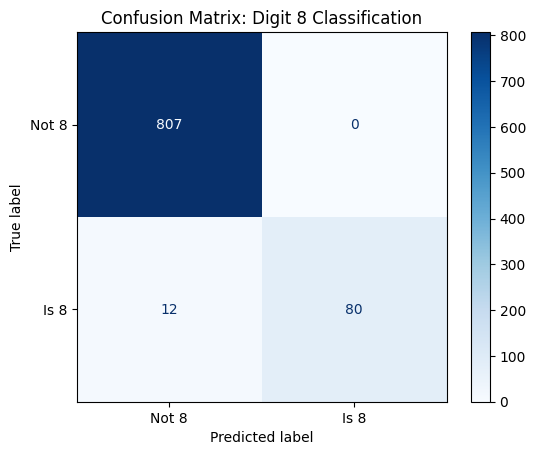


Confusion Matrix Breakdown:
True Negatives (correctly identified non-8s): 807
False Positives (incorrectly identified as 8s): 0
False Negatives (8s missed): 12
True Positives (correctly identified 8s): 80


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['Not 8', 'Is 8'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Digit 8 Classification')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (correctly identified non-8s): {tn}")
print(f"False Positives (incorrectly identified as 8s): {fp}")
print(f"False Negatives (8s missed): {fn}")
print(f"True Positives (correctly identified 8s): {tp}")

### 8. Conclusion

#### Key Takeaways
1. **Custom refit strategies** allow you to encode complex model selection criteria beyond simple metric maximization
2. **Multi-stage filtering** (precision → recall → speed) ensures you get a well-rounded model
3. **Real-world considerations** like inference speed often matter as much as raw performance metrics
4. **GridSearchCV's automatic refitting** provides a ready-to-use model trained on all available data

#### When to Use Custom Refit Strategies
Consider using a custom refit strategy when:
- You need to balance multiple competing metrics
- You have hard constraints (e.g., minimum precision threshold)
- Model complexity or inference speed matters for deployment
- Domain knowledge suggests specific selection criteria